# Figure 3 — model-derived HA1 mutation-reversion effects

This notebook is the single maintained source for Figure 3. At present it implements **panel A only**. It aggregates observed directed substitutions from the full-embedding counterfactual analysis using serum-balanced reversion effects.

In [96]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('/home/chenyh/workspace/fluProfiler')
RESULTS_ROOT = PROJECT_ROOT / 'results/H3_HA1_v1.0/20260827_112805'
ABLATION_DIR = RESULTS_ROOT / 'SCMS-FiLM-H3/full_data_interpretation/subtype/H3N2_seed42/mutation_ablation'
ANNOTATION_CSV = PROJECT_ROOT / 'paper/data/ABCDE.csv'
OUTPUT_DIR = PROJECT_ROOT / 'paper/Code/Fig3_mutation_reversion'

MIN_PAIRS = 60
MIN_SERUMS = 10
TOP_N = 40
N_LABELS = 10
CANONICAL_AMINO_ACIDS = set('ACDEFGHIKLMNPQRSTVWY')

EPITOPE_COLORS = {'A': '#FF8C1A', 'B': '#E52521', 'C': '#29A643', 'D': '#2383D7', 'E': '#7B43B6', 'Un': '#6E6E6E', 'Unannotated': '#B7B7B7'}

plt.rcParams.update({'font.family': 'DejaVu Sans', 'svg.fonttype': 'none', 'pdf.fonttype': 42})

## Load and serum-balance observed reversion effects

For every serum and directed substitution, the within-serum median reversion effect is first calculated across its observed pairs. The across-serum median then gives every serum equal weight.

In [97]:
pairs = pd.read_csv(ABLATION_DIR / 'original_pairs.csv')
counterfactuals = pd.read_csv(ABLATION_DIR / 'reverted_counterfactuals.csv')
reversion = pd.read_csv(ABLATION_DIR / 'full_embedding_reversion_deduplicated_long.csv')

effects = (
    reversion
    .merge(counterfactuals[['counterfactual_id', 'reverted_query_sequence']], on='counterfactual_id', how='left')
    .merge(pairs[['sample_index', 'serumName']], on='sample_index', how='left')
)
effects = effects.loc[
    effects['reference_aa'].isin(CANONICAL_AMINO_ACIDS)
    & effects['query_aa'].isin(CANONICAL_AMINO_ACIDS)
].copy()

serum_substitution = (
    effects.groupby(['serumName', 'aa_position', 'substitution'], as_index=False)
    .agg(serum_median_delta=('delta_mean', 'median'), n_pairs=('counterfactual_id', 'size'))
)
substitution_summary = (
    serum_substitution.groupby(['aa_position', 'substitution'], as_index=False)
    .agg(
        n_serums=('serumName', 'nunique'),
        n_pairs=('n_pairs', 'sum'),
        serum_balanced_mean_delta=('serum_median_delta', 'mean'),
        serum_balanced_median_delta=('serum_median_delta', 'median'),
    )
    .assign(abs_effect=lambda x: x['serum_balanced_median_delta'].abs())
)
candidate_substitutions = (
    substitution_summary.query('n_pairs >= @MIN_PAIRS and n_serums >= @MIN_SERUMS')
    .sort_values('abs_effect', ascending=False, kind='stable')
    .reset_index(drop=True)
)

print({'counterfactual_rows': len(effects), 'supported_substitutions': len(candidate_substitutions), 'supported_HA1_positions': candidate_substitutions['aa_position'].nunique(), 'min_pairs': MIN_PAIRS, 'min_serums': MIN_SERUMS})

{'counterfactual_rows': 533116, 'supported_substitutions': 289, 'supported_HA1_positions': 149, 'min_pairs': 60, 'min_serums': 10}


## Add classical H3 HA1 epitope annotation and inspect the plotted data

In [98]:
annotations = pd.read_csv(ANNOTATION_CSV).rename(columns={'Amino acid residues of HA1': 'aa_position', 'Antigenic epitope': 'epitope'})
plot_table = (
    candidate_substitutions
    .merge(annotations[['aa_position', 'epitope']], on='aa_position', how='left')
    .assign(epitope=lambda x: x['epitope'].where(x['epitope'].isin(list('ABCDE') + ['Un']), 'Unannotated'))
    .sort_values(['aa_position', 'substitution'], kind='stable')
    .reset_index(drop=True)
)

top_substitutions = plot_table.nlargest(TOP_N, 'abs_effect').copy()
summary = pd.DataFrame([{
    'supported substitutions': len(plot_table),
    'HA1 positions': plot_table['aa_position'].nunique(),
    f'Top {TOP_N} in A-E epitopes': f"{top_substitutions['epitope'].isin(list('ABCDE')).sum()}/{TOP_N} ({top_substitutions['epitope'].isin(list('ABCDE')).mean():.1%})",
    'candidate background in A-E': f"{plot_table['epitope'].isin(list('ABCDE')).mean():.1%}",
}])
print('Panel A summary:')
print(summary.to_string(index=False))
display(top_substitutions[['aa_position', 'substitution', 'serum_balanced_median_delta', 'n_pairs', 'n_serums', 'epitope']])

Panel A summary:
 supported substitutions  HA1 positions Top 40 in A-E epitopes candidate background in A-E
                     289            149          32/40 (80.0%)                       64.4%


,aa_position,substitution,serum_balanced_median_delta,n_pairs,n_serums,epitope
185,189,K→R,1.378327,769,33,B
177,183,H→L,1.239445,104,51,Unannotated
234,225,N→D,0.730156,3631,39,D
147,158,N→K,0.705148,532,51,B
181,186,G→S,-0.669390,106,26,B
169,168,M→V,0.660126,129,26,Unannotated
109,131,K→T,0.636128,1810,30,A
188,190,N→T,0.613313,60,21,B
193,193,S→F,0.603535,966,18,B
230,223,V→I,0.603003,5325,36,Unannotated


## Top 40 substitutions: unique HA1 positions by epitope

A position is counted once even if multiple directed substitutions at that position occur in the top 40. `Un` denotes the reported unknown-epitope category; positions absent from the annotation table are reported separately as `Unannotated`.

In [99]:
top40_unique_sites = (
    top_substitutions
    .sort_values('abs_effect', ascending=False, kind='stable')
    .drop_duplicates('aa_position')
    .assign(epitope_group=lambda x: x['epitope'].where(x['epitope'].isin(list('ABCDE') + ['Un']), 'Unannotated'))
)

top40_unique_site_summary = (
    top40_unique_sites.groupby('epitope_group', sort=False)
    .agg(
        n_unique_HA1_positions=('aa_position', 'nunique'),
        HA1_positions=('aa_position', lambda x: ', '.join(map(str, sorted(x)))),
    )
    .reindex(list('ABCDE') + ['Un', 'Unannotated'])
    .fillna({'n_unique_HA1_positions': 0, 'HA1_positions': ''})
)
top40_unique_site_summary['n_unique_HA1_positions'] = top40_unique_site_summary['n_unique_HA1_positions'].astype(int)

print(f'Top {TOP_N} substitutions contain {len(top40_unique_sites)} unique HA1 positions.')
display(top40_unique_site_summary)

Top 40 substitutions contain 34 unique HA1 positions.


,n_unique_HA1_positions,HA1_positions
epitope_group,,
A,5,"131, 137, 140, 144, 145"
B,9,"156, 158, 159, 186, 189, 190, 193, 194, 197"
C,4,"50, 53, 54, 276"
D,5,"172, 173, 201, 222, 225"
E,3,"62, 65, 75"
Un,1,202
Unannotated,7,"49, 168, 183, 223, 228, 233, 310"


## Panel A — HA1 mutation-reversion effect spectrum

Each point is a supported directed substitution. Colour indicates the classical epitope assigned to its HA1 position; the narrow segmented strip above the plot marks contiguous runs of the actual, discontinuous A–E residue annotations from `ABCDE.csv`. Positive values indicate that reverting the observed query residue lowers the model-predicted antigenic distance.

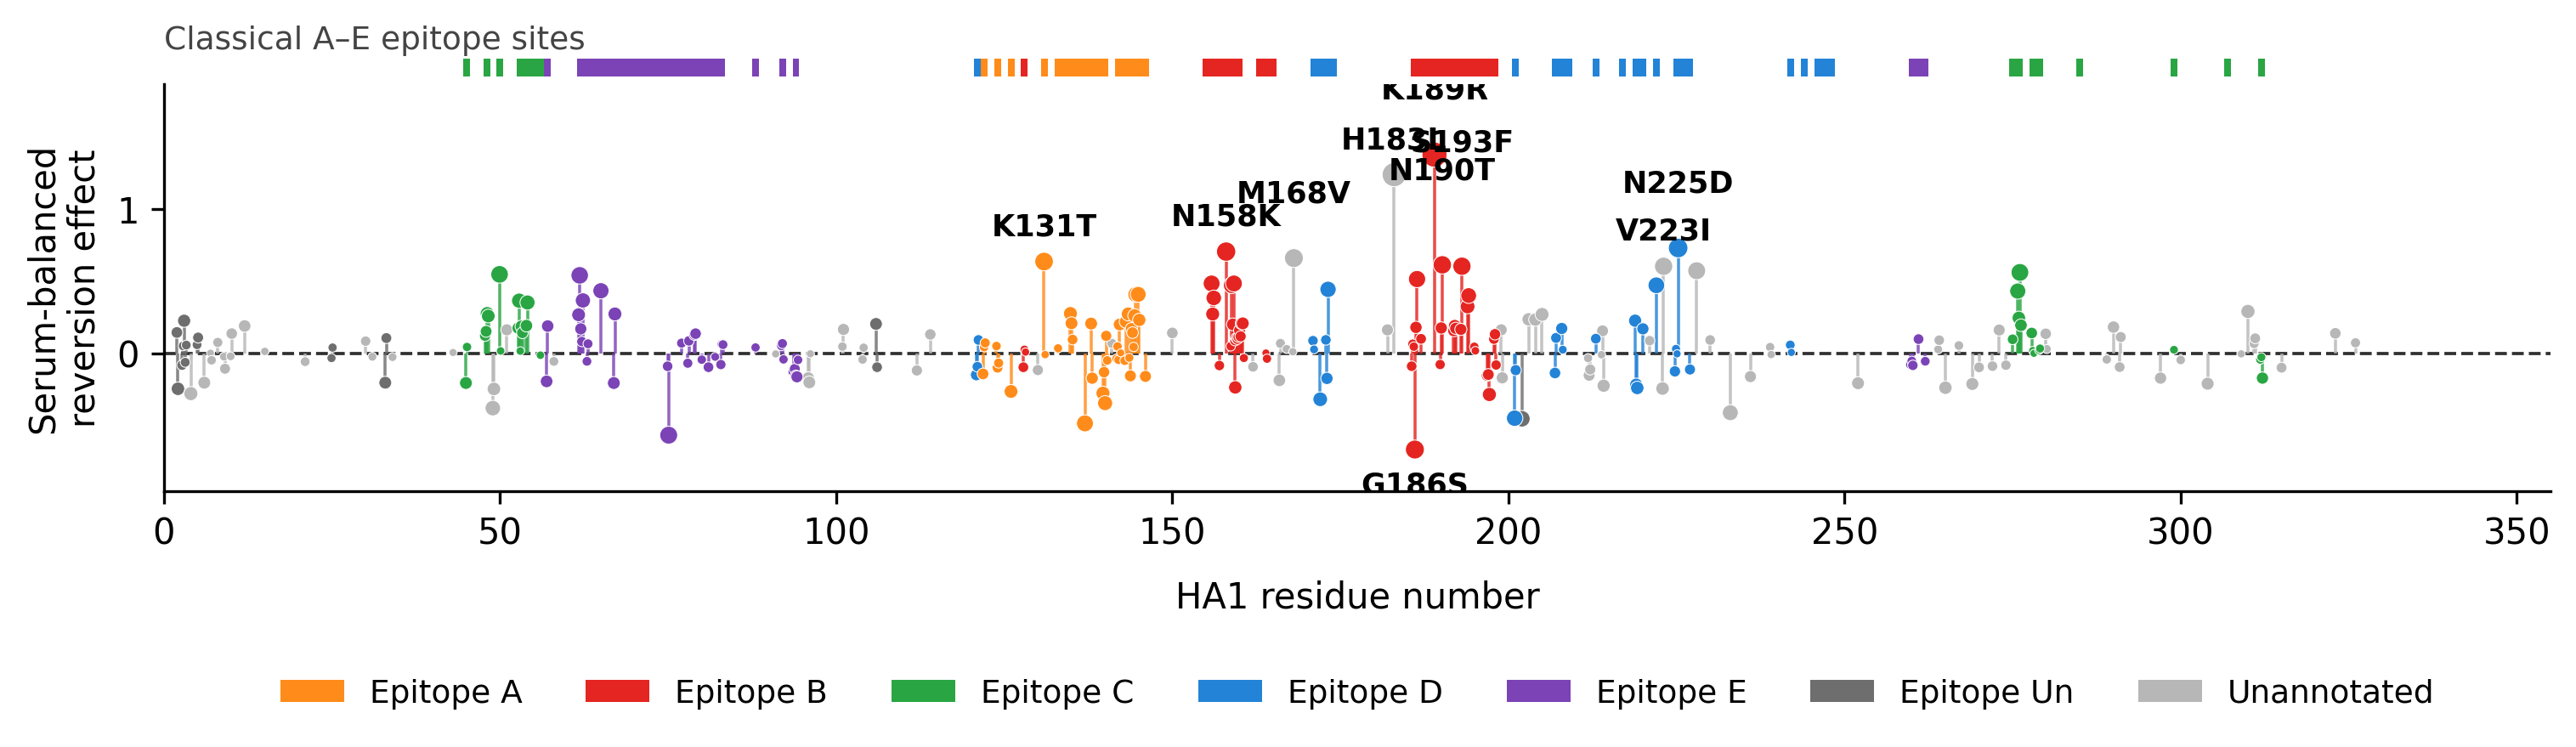

Wrote panel A and tables to: /home/chenyh/workspace/fluProfiler/paper/Code/Fig3_mutation_reversion


In [100]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10.4, 3.8), dpi=300)
epitope_sites = annotations.loc[annotations['epitope'].isin(list('ABCDE')), ['aa_position', 'epitope']].drop_duplicates()
def contiguous_runs(positions):
    positions = sorted(set(int(position) for position in positions))
    if not positions:
        return []
    runs, start, previous = [], positions[0], positions[0]
    for position in positions[1:]:
        if position != previous + 1:
            runs.append((start, previous))
            start = position
        previous = position
    runs.append((start, previous))
    return runs

for epitope, group in epitope_sites.groupby('epitope'):
    for start, end in contiguous_runs(group['aa_position']):
        ax.add_patch(Rectangle((start - 0.5, 1.018), end - start + 1, 0.045, transform=ax.get_xaxis_transform(), facecolor=EPITOPE_COLORS[epitope], edgecolor='none', clip_on=False, zorder=5))
ax.text(0.0, 1.07, 'Classical A–E epitope sites', transform=ax.transAxes, ha='left', va='bottom', fontsize=9, color='#444444')

# Small deterministic offsets separate multiple substitutions at one HA1 position.
plot_data = plot_table.copy()
plot_data['within_site_order'] = plot_data.groupby('aa_position').cumcount()
plot_data['within_site_n'] = plot_data.groupby('aa_position')['substitution'].transform('size')
plot_data['x'] = plot_data['aa_position'] + (plot_data['within_site_order'] - (plot_data['within_site_n'] - 1) / 2) * 0.16
effect_min = plot_data['serum_balanced_median_delta'].min()
effect_max = plot_data['serum_balanced_median_delta'].max()
effect_span = effect_max - effect_min
effect_scale = plot_data['serum_balanced_median_delta'].abs().max()
plot_data['marker_size'] = 5 + 45 * (plot_data['serum_balanced_median_delta'].abs() / effect_scale) ** 0.9
for epitope, group in plot_data.groupby('epitope', sort=False):
    color = EPITOPE_COLORS[epitope]
    ax.vlines(group['x'], 0, group['serum_balanced_median_delta'], color=color, lw=0.85, alpha=0.82, zorder=2)
    ax.scatter(group['x'], group['serum_balanced_median_delta'], s=group['marker_size'], color=color, edgecolor='white', linewidth=0.25, zorder=3)

ax.axhline(0, color='#303030', lw=0.9, ls='--', zorder=1)
labels = plot_data.nlargest(N_LABELS, 'abs_effect').sort_values('aa_position')
effect_min = plot_data['serum_balanced_median_delta'].min()
effect_max = plot_data['serum_balanced_median_delta'].max()
effect_span = effect_max - effect_min
def assign_label_lanes(label_group, min_x_gap=13):
    lane_last_x = []
    assignments = {}
    for row_index, row in label_group.sort_values('x').iterrows():
        lane = next((i for i, last_x in enumerate(lane_last_x) if row['x'] - last_x >= min_x_gap), len(lane_last_x))
        if lane == len(lane_last_x):
            lane_last_x.append(row['x'])
        else:
            lane_last_x[lane] = row['x']
        assignments[row_index] = lane
    return label_group.assign(label_lane=pd.Series(assignments)), len(lane_last_x)

positive_labels, n_positive_lanes = assign_label_lanes(labels.loc[labels['serum_balanced_median_delta'] >= 0])
negative_labels, n_negative_lanes = assign_label_lanes(labels.loc[labels['serum_balanced_median_delta'] < 0])
positive_labels = positive_labels.assign(label_y=lambda x: x['serum_balanced_median_delta'] + (0.07 + 0.10 * x['label_lane']) * effect_span)
negative_labels = negative_labels.assign(label_y=lambda x: x['serum_balanced_median_delta'] - (0.07 + 0.10 * x['label_lane']) * effect_span)
label_top = max(effect_max, positive_labels['label_y'].max() if len(positive_labels) else effect_max) + 0.07 * effect_span
label_bottom = min(effect_min, negative_labels['label_y'].min() if len(negative_labels) else effect_min) - 0.07 * effect_span
for direction, label_group in ((1, positive_labels), (-1, negative_labels)):
    for _, row in label_group.iterrows():
        lane = int(row['label_lane'])
        label_y = row['label_y']
        ax.annotate(
            row['substitution'].replace('→', str(int(row['aa_position']))),
            xy=(row['x'], row['serum_balanced_median_delta']), xytext=(row['x'], label_y), textcoords='data',
            ha='center', va='bottom' if direction > 0 else 'top', fontsize=8.4, fontweight='bold', clip_on=True,
        )
ax.set_ylim(label_bottom, label_top)

handles = [Patch(facecolor=EPITOPE_COLORS[e], edgecolor='none', label=f'Epitope {e}') for e in 'ABCDE'] + [Patch(facecolor=EPITOPE_COLORS['Un'], edgecolor='none', label='Epitope Un'), Patch(facecolor=EPITOPE_COLORS['Unannotated'], edgecolor='none', label='Unannotated')]
ax.legend(handles=handles, ncol=7, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.39), fontsize=9)
ax.set(xlim=(0, 355), xlabel='HA1 residue number', ylabel='Serum-balanced\nreversion effect')
ax.xaxis.labelpad = 8
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)
fig.subplots_adjust(left=0.08, right=0.98, bottom=0.40, top=0.82)

for suffix in ('svg', 'pdf', 'png'):
    fig.savefig(OUTPUT_DIR / f'Fig3A_HA1_mutation_reversion_effects.{suffix}', dpi=600, bbox_inches='tight', pad_inches=0.03)
plt.show()

plot_table.to_csv(OUTPUT_DIR / 'Fig3A_supported_substitution_effects.csv', index=False)
top_substitutions.to_csv(OUTPUT_DIR / 'Fig3A_top_substitutions.csv', index=False)
print(f'Wrote panel A and tables to: {OUTPUT_DIR}')

## Panel B — Top 40 high-effect HA1 substitutions grouped by antigenic epitope

The table reports directed substitutions, rather than residue positions. Within each epitope category, substitutions are ordered by descending absolute serum-balanced reversion effect. `Other epitope` corresponds to the reported `Un` category; `Unannotated` identifies positions absent from the epitope annotation table.


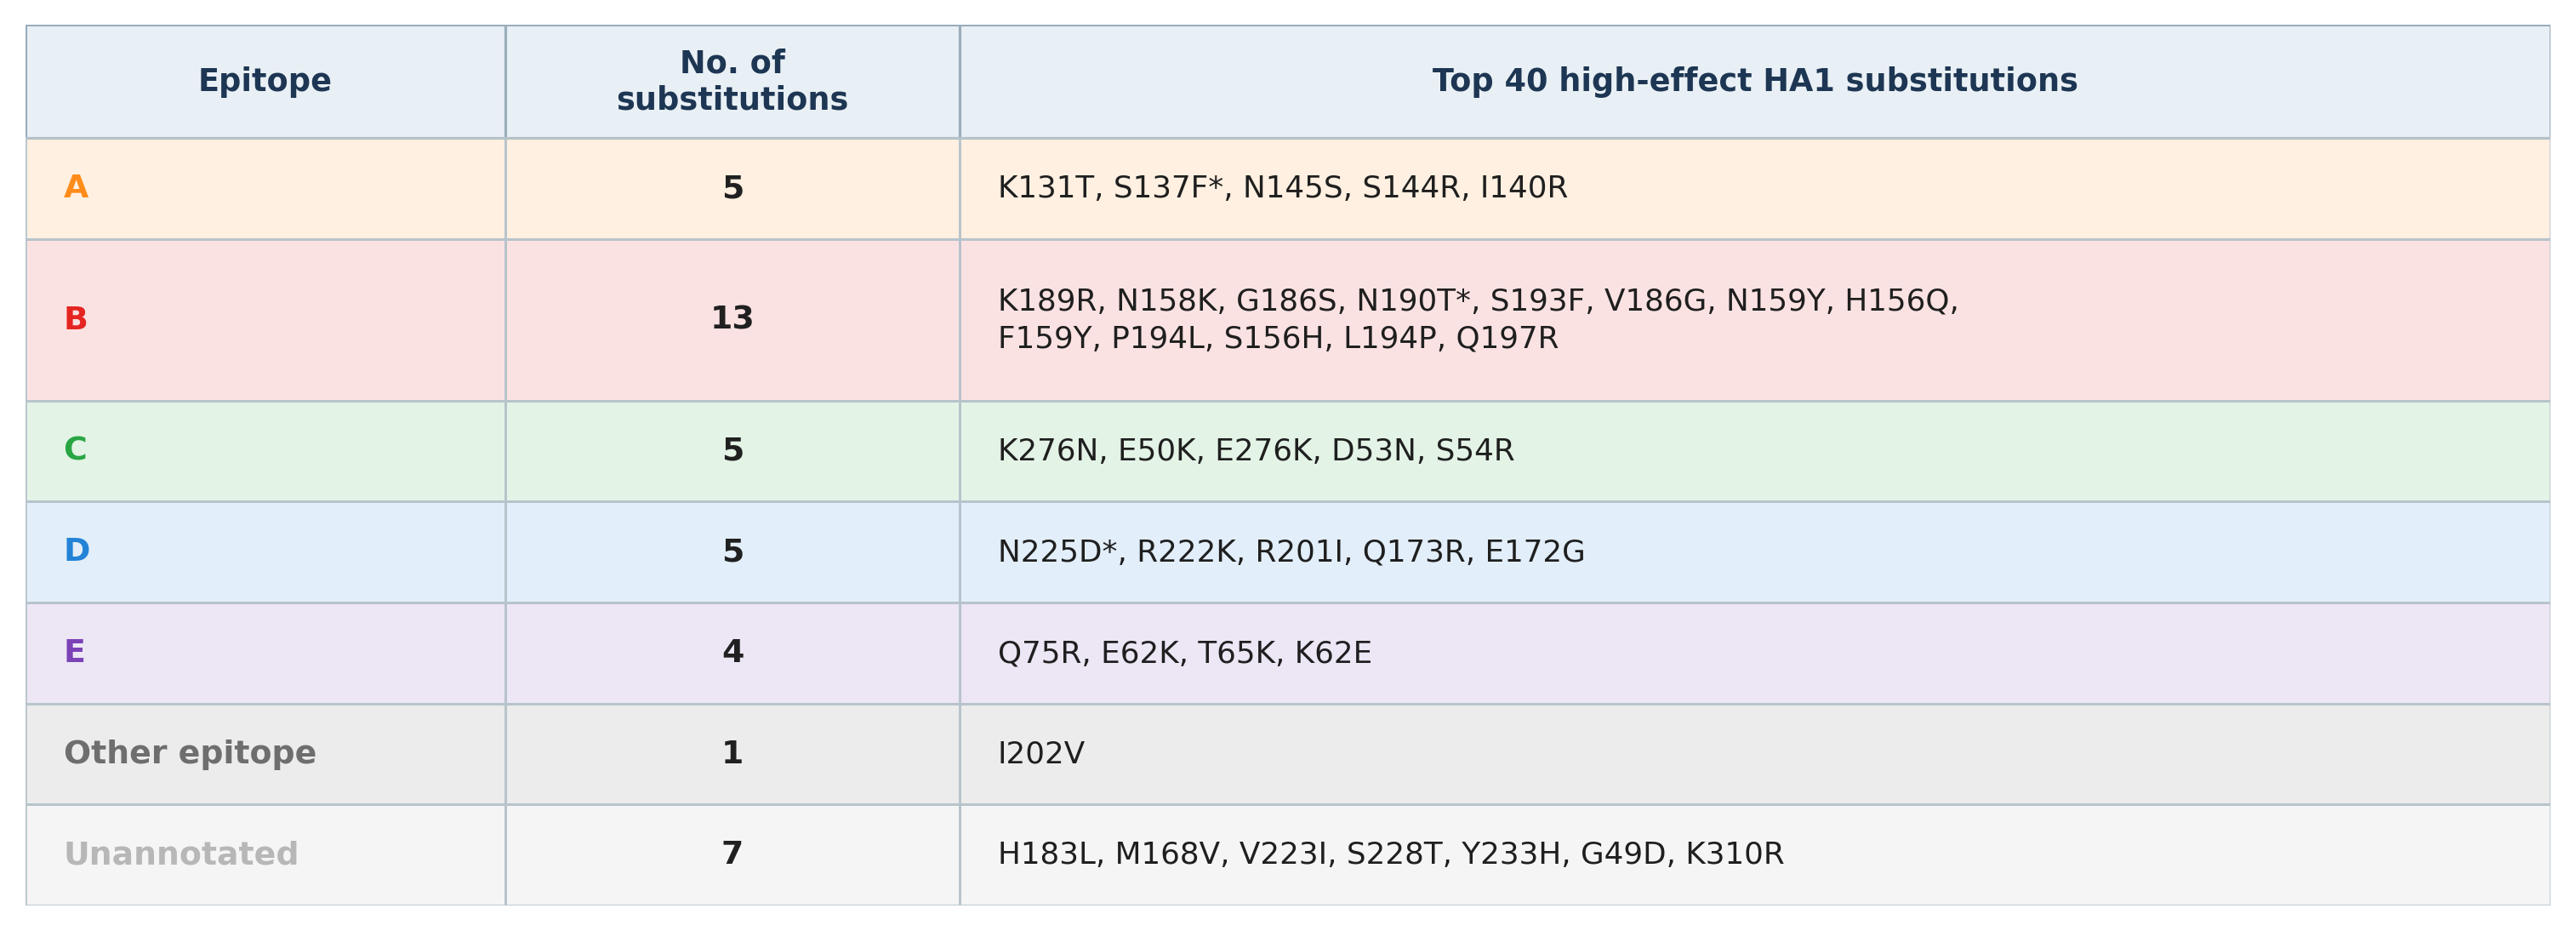

Panel B: 40 directed substitutions across 7 epitope groups. Wrote figure and tables to: /home/chenyh/workspace/fluProfiler/paper/Code/Fig3_mutation_reversion


,epitope_code,Epitope,No. of substitutions,Top 40 high-effect HA1 substitutions
0,A,A,5,"K131T, S137F*, N145S, S144R, I140R"
1,B,B,13,"K189R, N158K, G186S, N190T*, S193F, V186G, N15..."
2,C,C,5,"K276N, E50K, E276K, D53N, S54R"
3,D,D,5,"N225D*, R222K, R201I, Q173R, E172G"
4,E,E,4,"Q75R, E62K, T65K, K62E"
5,Un,Other epitope,1,I202V
6,Unannotated,Unannotated,7,"H183L, M168V, V223I, S228T, Y233H, G49D, K310R"


In [101]:
# Panel B: top 40 high-effect directed substitutions grouped by epitope.
import textwrap
from matplotlib import colors as mcolors

PANEL_B_GROUPS = [
    ('A', 'A'),
    ('B', 'B'),
    ('C', 'C'),
    ('D', 'D'),
    ('E', 'E'),
    ('Un', 'Other epitope'),
    ('Unannotated', 'Unannotated'),
]

rbs_positions_b = set(
    annotations.loc[annotations['Receptor binding site'].fillna('').astype(str).str.strip().eq('√'), 'aa_position']
    .astype(int)
)

panel_b_data = top_substitutions.copy()
panel_b_data['mutation_label'] = panel_b_data.apply(
    lambda row: f"{row['substitution'].split('→')[0]}{int(row['aa_position'])}{row['substitution'].split('→')[-1]}",
    axis=1,
)
panel_b_data['is_rbs_associated'] = panel_b_data['aa_position'].astype(int).isin(rbs_positions_b)
panel_b_data['display_substitution'] = panel_b_data['mutation_label'] + panel_b_data['is_rbs_associated'].map({True: '*', False: ''})
panel_b_data['display_epitope'] = panel_b_data['epitope'].map(dict(PANEL_B_GROUPS))
panel_b_data = panel_b_data.sort_values('abs_effect', ascending=False, kind='stable').reset_index(drop=True)

panel_b_rows = []
for epitope_code, display_epitope in PANEL_B_GROUPS:
    group = panel_b_data.loc[panel_b_data['epitope'].eq(epitope_code)].copy()
    substitution_text = ', '.join(group['display_substitution']) if len(group) else '—'
    wrapped = textwrap.wrap(
        substitution_text, width=56, break_long_words=False, break_on_hyphens=False,
    ) or ['—']
    panel_b_rows.append({
        'epitope_code': epitope_code,
        'Epitope': display_epitope,
        'No. of substitutions': len(group),
        'Top 40 high-effect HA1 substitutions': '\n'.join(wrapped),
        'n_lines': len(wrapped),
    })
panel_b_table = pd.DataFrame(panel_b_rows)

# Rectangular vector table: all text remains selectable/editable in the SVG/PDF.
column_edges = [0.00, 0.19, 0.37, 1.00]
title_height = 0.00
header_height = 0.56
footer_height = 0.00
panel_b_table['row_height'] = 0.50 + 0.30 * (panel_b_table['n_lines'] - 1)
total_height = title_height + header_height + panel_b_table['row_height'].sum() + footer_height
fig, ax = plt.subplots(figsize=(10.2, max(3.65, total_height * 0.67)), dpi=300)
ax.set_xlim(0, 1)
ax.set_ylim(total_height, 0)
ax.axis('off')

header_y = title_height
headers = ['Epitope', 'No. of\nsubstitutions', 'Top 40 high-effect HA1 substitutions']
for left, right, header in zip(column_edges[:-1], column_edges[1:], headers):
    ax.add_patch(plt.Rectangle((left, header_y), right - left, header_height, facecolor='#E9F0F5', edgecolor='#9AAEBC', linewidth=0.75))
    ax.text((left + right) / 2, header_y + header_height / 2, header, ha='center', va='center', fontsize=8.8, fontweight='bold', color='#1D3653')

current_y = header_y + header_height
for _, row in panel_b_table.iterrows():
    row_height = row['row_height']
    row_color = EPITOPE_COLORS[row['epitope_code']]
    row_facecolor = mcolors.to_rgba(row_color, alpha=0.13)
    for left, right in zip(column_edges[:-1], column_edges[1:]):
        ax.add_patch(plt.Rectangle((left, current_y), right - left, row_height, facecolor=row_facecolor, edgecolor='#B7C4CC', linewidth=0.65))
    ax.text(0.015, current_y + row_height / 2, row['Epitope'], ha='left', va='center', fontsize=9.1, fontweight='bold', color=row_color)
    ax.text((column_edges[1] + column_edges[2]) / 2, current_y + row_height / 2, str(int(row['No. of substitutions'])), ha='center', va='center', fontsize=9.1, fontweight='bold', color='#202020')
    ax.text(column_edges[2] + 0.015, current_y + row_height / 2, row['Top 40 high-effect HA1 substitutions'], ha='left', va='center', fontsize=8.6, color='#1F1F1F', linespacing=1.38)
    current_y += row_height

fig.subplots_adjust(left=0.025, right=0.995, top=0.985, bottom=0.04)

for extension in ('svg', 'pdf', 'png'):
    fig.savefig(OUTPUT_DIR / f'Fig3B_top40_substitutions_by_epitope.{extension}', bbox_inches='tight', dpi=300)
plt.show()

panel_b_data.to_csv(OUTPUT_DIR / 'Fig3B_top40_substitutions_detailed.csv', index=False)
panel_b_table.drop(columns=['n_lines', 'row_height']).to_csv(OUTPUT_DIR / 'Fig3B_top40_substitutions_by_epitope.csv', index=False)
print(f'Panel B: {len(panel_b_data)} directed substitutions across {len(panel_b_table)} epitope groups. Wrote figure and tables to: {OUTPUT_DIR}')
display(panel_b_table.drop(columns=['n_lines', 'row_height']))


## Panel C — Enrichment of high-effect substitutions in classical epitopes

This test asks whether the top 40 high-effect directed substitutions are enriched in classical antigenic epitopes A–E relative to all supported substitutions. The null distribution is generated by sampling 40 substitutions without replacement from the supported candidate set (10,000 permutations; fixed seed for reproducibility). `Un` and `Unannotated` are both outside the A–E set for this specific enrichment test.


Panel C enrichment test:


,top_n_substitutions,observed_A_to_E_substitutions,observed_A_to_E_fraction,supported_substitutions,background_A_to_E_substitutions,background_A_to_E_fraction,n_permutations,permutation_seed,one_sided_p_value
0,40,32,0.8,289,186,0.643599,10000,42,0.015698


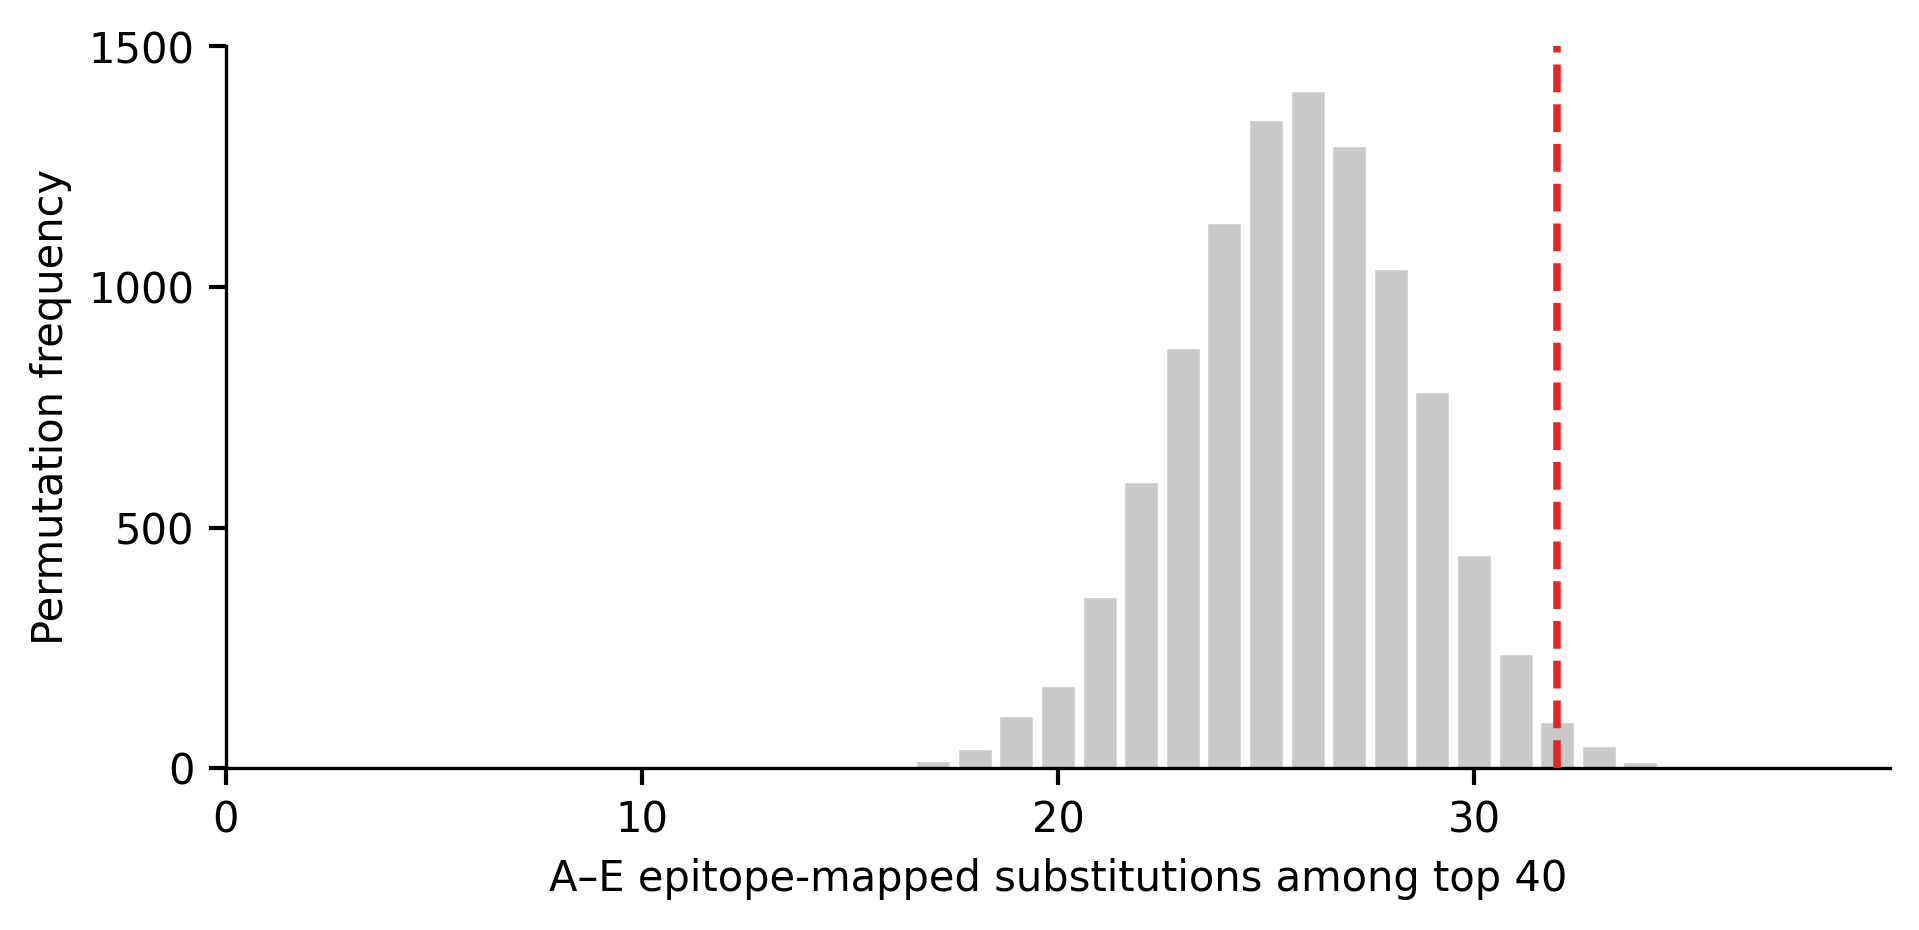

Wrote Panel C figure and tables to: /home/chenyh/workspace/fluProfiler/paper/Code/Fig3_mutation_reversion


In [102]:
# Panel C: permutation test for enrichment in classical A–E epitopes
N_PERMUTATIONS = 10_000
PERMUTATION_SEED = 42
CLASSICAL_EPITOPES = list('ABCDE')

is_classical = plot_table['epitope'].isin(CLASSICAL_EPITOPES)
observed_count = int(top_substitutions['epitope'].isin(CLASSICAL_EPITOPES).sum())
n_draw = len(top_substitutions)
n_classical_background = int(is_classical.sum())
n_other_background = int((~is_classical).sum())

# Hypergeometric sampling is equivalent to drawing TOP_N substitutions without
# replacement from the supported candidate set under the null hypothesis.
rng = np.random.default_rng(PERMUTATION_SEED)
permutation_counts = rng.hypergeometric(
    ngood=n_classical_background,
    nbad=n_other_background,
    nsample=n_draw,
    size=N_PERMUTATIONS,
)

n_at_least_as_extreme = int((permutation_counts >= observed_count).sum())
permutation_p = (n_at_least_as_extreme + 1) / (N_PERMUTATIONS + 1)
background_fraction = n_classical_background / len(plot_table)

panel_c_summary = pd.DataFrame([{
    'top_n_substitutions': n_draw,
    'observed_A_to_E_substitutions': observed_count,
    'observed_A_to_E_fraction': observed_count / n_draw,
    'supported_substitutions': len(plot_table),
    'background_A_to_E_substitutions': n_classical_background,
    'background_A_to_E_fraction': background_fraction,
    'n_permutations': N_PERMUTATIONS,
    'permutation_seed': PERMUTATION_SEED,
    'one_sided_p_value': permutation_p,
}])
permutation_distribution = (
    pd.Series(permutation_counts, name='n_A_to_E_substitutions')
    .value_counts()
    .sort_index()
    .rename_axis('n_A_to_E_substitutions')
    .reset_index(name='permutation_frequency')
)

print('Panel C enrichment test:')
display(panel_c_summary)

fig, ax = plt.subplots(figsize=(6.5, 3.2), dpi=300)
counts = pd.Series(permutation_counts).value_counts().sort_index()
x_values = np.arange(int(counts.index.min()), int(counts.index.max()) + 1)
y_values = counts.reindex(x_values, fill_value=0)
ax.bar(x_values, y_values, width=0.82, color='#C9C9C9', edgecolor='white', linewidth=0.35, zorder=2)
ax.axvline(observed_count, color='#E52521', lw=1.8, ls='--', zorder=4)
# ax.text(
#     observed_count + 0.6,
#     ax.get_ylim()[1] * 0.92,
#     f'Observed: {observed_count}/{n_draw} ({observed_count / n_draw:.1%})\n'
#     f'Candidate background: {background_fraction:.1%}\n'
#     f'One-sided P = {permutation_p:.4f}\n'
#     f'{N_PERMUTATIONS:,} permutations',
#     ha='left', va='top', fontsize=9.5, color='#222222',
# )
ax.set(
    xlabel=f'A–E epitope-mapped substitutions among top {n_draw}',
    ylabel='Permutation frequency',
    xlim=(max(0, x_values.min() - 1), max(observed_count + 8, x_values.max() + 1)),
)
ax.set_xticks(np.arange(0, max(observed_count + 8, x_values.max() + 1), 10))
ax.set_yticks(np.arange(0, 1600, 500))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(width=1.0, length=4)
fig.tight_layout()

for extension in ('svg', 'pdf', 'png'):
    fig.savefig(OUTPUT_DIR / f'Fig3C_epitope_enrichment.{extension}', bbox_inches='tight', dpi=300)
plt.show()

panel_c_summary.to_csv(OUTPUT_DIR / 'Fig3C_epitope_enrichment_summary.csv', index=False)
permutation_distribution.to_csv(OUTPUT_DIR / 'Fig3C_epitope_enrichment_permutation_distribution.csv', index=False)
print(f'Wrote Panel C figure and tables to: {OUTPUT_DIR}')
